## Prac 06.2

In this homework, you are going to use and compare two different trackers (of your liking) and compare the results.

### Step 1
Decide what video you are going to use for this homework, select an object and generate the template. You can use any video you want (your own, from Youtube, etc.)
and track any object you want (e.g. a car, a pedestrian, etc.).

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import math

In [56]:
video_path = 'sakhir_2020_63.mp4'
num_frames = 150

x1, y1 = 480, 320 
x2, y2 = 590, 380 

width = x2 - x1
height = y2 - y1
bbox = (x1, y1, width, height)

### Step 2
Initialize a tracker (e.g. KCF).

In [57]:
os.makedirs('KCF', exist_ok=True)
tracker = cv2.TrackerKCF_create()

cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
ok = tracker.init(frame, bbox)

### Step 3
Run the tracker on the video and the selected object. Run the tracker for around 10-15 frames.

### Step 4
For each frame, print the bounding box on the image and save it.



In [58]:
tracked_frames = []

for ii in range(num_frames):
    ret, frame = cap.read()
    if not ret:
        break
        
    ok, current_bbox = tracker.update(frame)
    
    if ok:
        p1 = (int(current_bbox[0]), int(current_bbox[1]))
        p2 = (int(current_bbox[0] + current_bbox[2]), int(current_bbox[1] + current_bbox[3]))
        cv2.rectangle(frame, p1, p2, (0, 255, 0), 2)
        cv2.putText(frame, 'KCF', (p1[0], p1[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    else:
        cv2.putText(frame, "Tracking failure detected", (100, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0, 0, 255), 2)

    save_path = os.path.join('KCF', f"frame_{ii+1:03d}.jpg")
    cv2.imwrite(save_path, frame)
    
    if ii == 0 or (ii + 1) % 10 == 0:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        tracked_frames.append((ii + 1, frame_rgb))

cap.release()

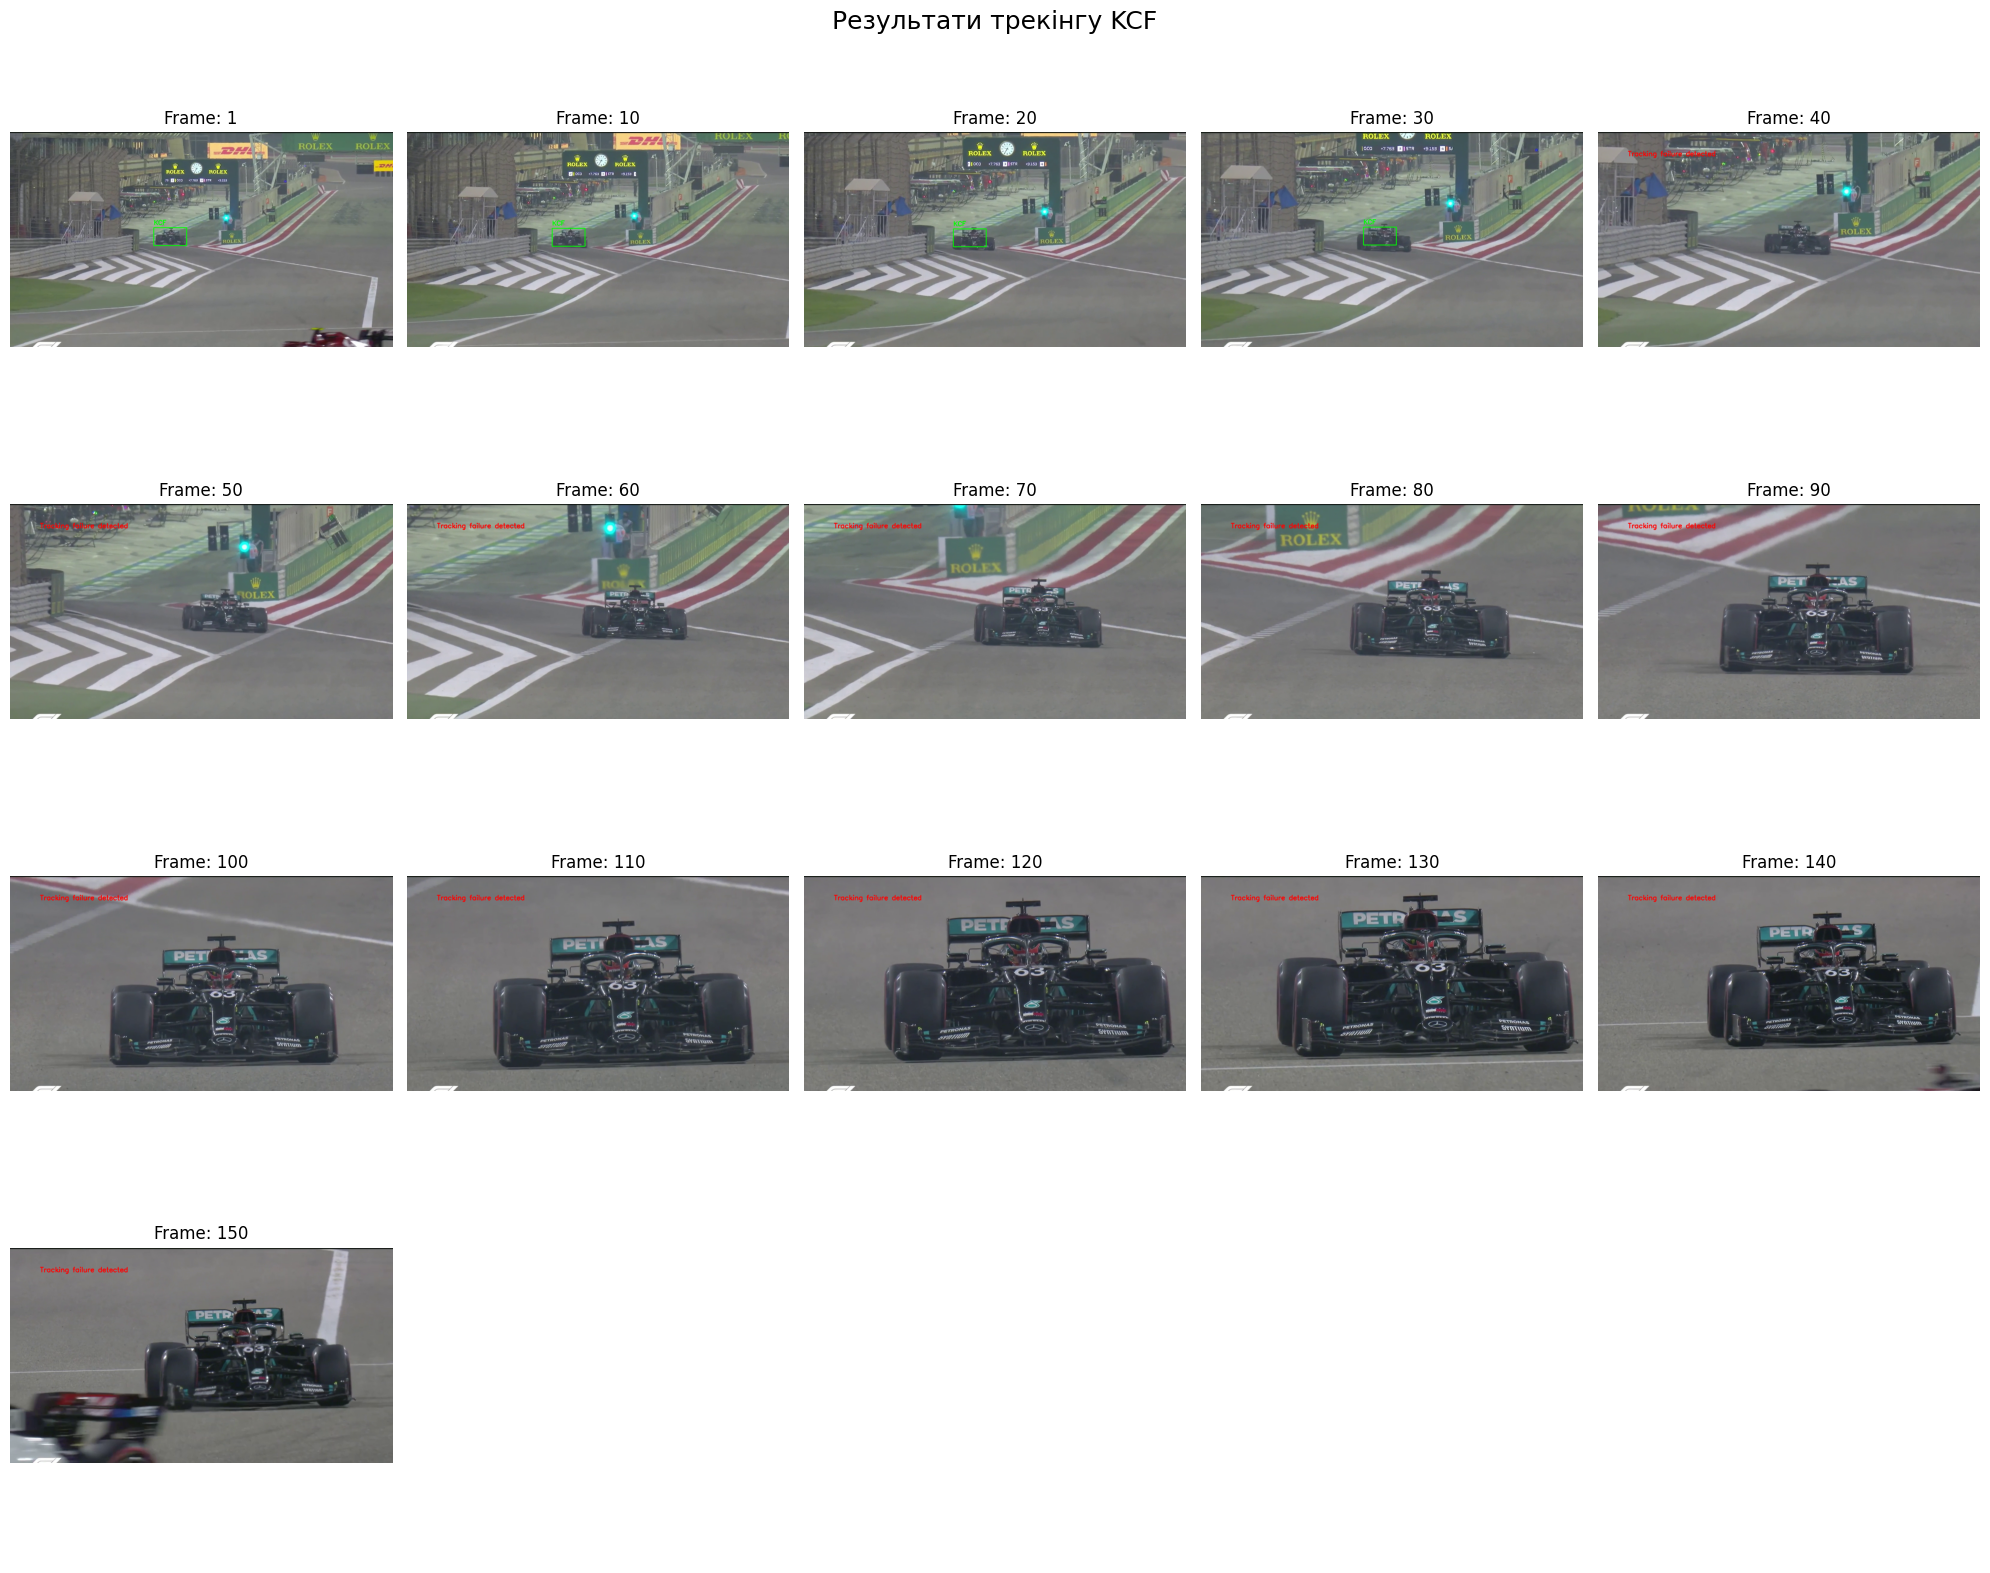

In [59]:
cols = 5
rows = math.ceil(len(tracked_frames) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
fig.suptitle('Результати трекінгу KCF', fontsize=18)

if rows == 1:
    axes = np.array([axes])
axes = axes.flatten()

for i in range(len(axes)):
    if i < len(tracked_frames):
        frame_num, img = tracked_frames[i]
        axes[i].imshow(img)
        axes[i].set_title(f"Frame: {frame_num}")
        axes[i].axis('off')
    else:
        axes[i].axis('off')

plt.tight_layout()
plt.show()

### Step 5
Select a different tracker (e.g. CSRT) and repeat steps 2, 3 and 4.



In [63]:
os.makedirs('CSRT', exist_ok=True)
tracker = cv2.TrackerCSRT_create()

cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
ok = tracker.init(frame, bbox)

In [64]:
tracked_frames = []

for ii in range(num_frames):
    ret, frame = cap.read()
    if not ret:
        break
        
    ok, current_bbox = tracker.update(frame)
    
    if ok:
        p1 = (int(current_bbox[0]), int(current_bbox[1]))
        p2 = (int(current_bbox[0] + current_bbox[2]), int(current_bbox[1] + current_bbox[3]))
        cv2.rectangle(frame, p1, p2, (0, 255, 0), 2)
        cv2.putText(frame, 'CSRT', (p1[0], p1[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    else:
        cv2.putText(frame, "Tracking failure detected", (100, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0, 0, 255), 2)

    save_path = os.path.join('CSRT', f"frame_{ii+1:03d}.jpg")
    cv2.imwrite(save_path, frame)
    
    if ii == 0 or (ii + 1) % 10 == 0:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        tracked_frames.append((ii + 1, frame_rgb))

cap.release()

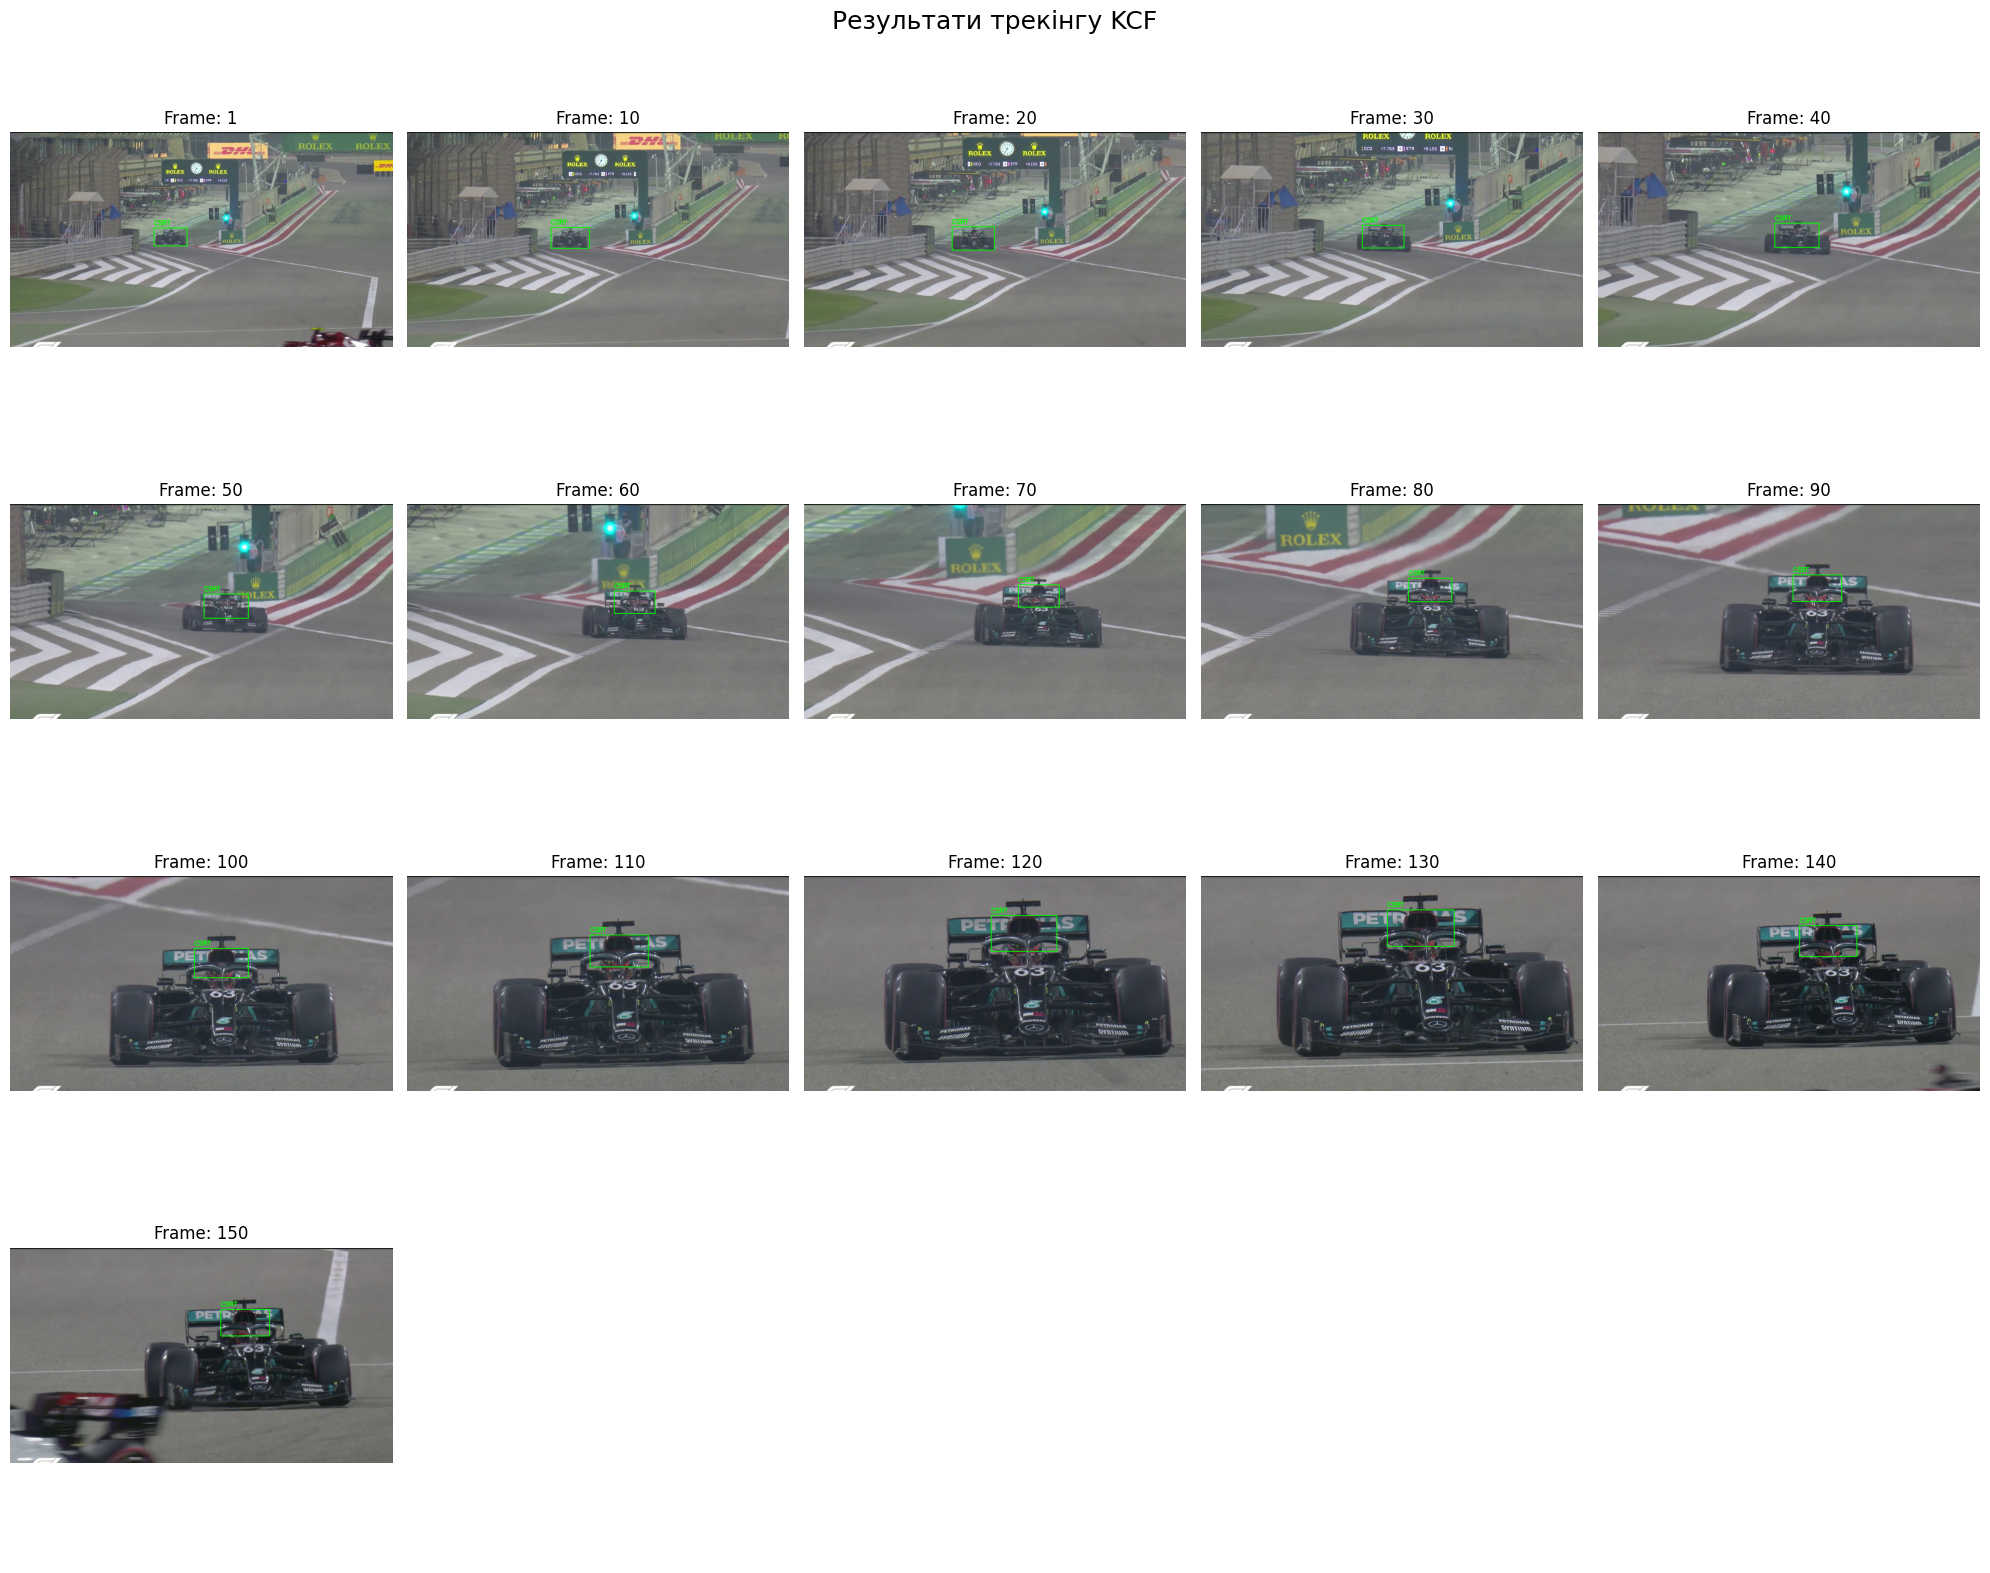

In [65]:
cols = 5
rows = math.ceil(len(tracked_frames) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
fig.suptitle('Результати трекінгу KCF', fontsize=18)

if rows == 1:
    axes = np.array([axes])
axes = axes.flatten()

for i in range(len(axes)):
    if i < len(tracked_frames):
        frame_num, img = tracked_frames[i]
        axes[i].imshow(img)
        axes[i].set_title(f"Frame: {frame_num}")
        axes[i].axis('off')
    else:
        axes[i].axis('off')

plt.tight_layout()
plt.show()

### Step 6
Compare the results:
* Do you see any differences? If so, what are they?
* Does one tracker perform better than the other? In what way?